# Computational Astrophysics: Day 1

## Fast Computation and Nearest-Neighbour Searches

**Kris Sens**

This notebook follows the process from Day 1 in the order that I worked through it. It combines the Python work with the explanations from my notes.

The main reading was **Chapter 2 of _Statistics, Data Mining and Machine Learning in Astronomy_**.

## 1. Why Fast Computation Matters

Modern astronomical surveys can contain millions or even billions of objects. Therefore, an algorithm which works well for a small sample may become unusable when applied to a full survey.

The important question is not only how long an algorithm takes for one value of \(N\), but how quickly its runtime increases as \(N\) becomes larger.

## 2. Algorithmic Scaling

The efficiency of an algorithm depends on how its runtime changes with the number of data points, \(N\).

- Sorting algorithms commonly scale approximately as \(O(N\log N)\).
- A simple nested-loop nearest-neighbour search scales as \(O(N^2)\).
- Under favourable conditions, a tree can reduce a single nearest-neighbour query to approximately \(O(\log N)\).

If the sample size increases by a factor of ten, an \(O(N^2)\) calculation may take roughly one hundred times longer.

## Imports

These are the packages used during the different parts of the work.

In [1]:
import scipy.stats
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.spatial import cKDTree
from sklearn.neighbors import BallTree

## Initial distribution plotting practice

Before moving onto the astronomical dataset, I briefly used SciPy distributions and Matplotlib to brush up on constructing and plotting probability density functions.

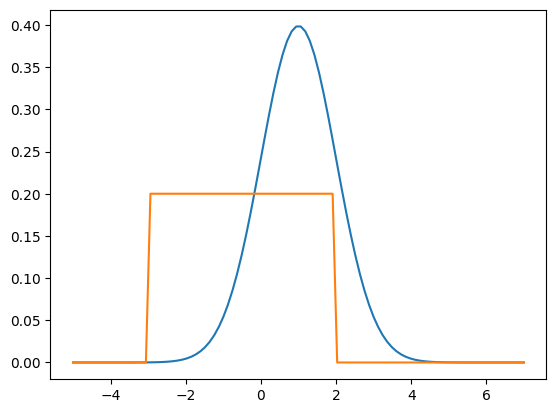

In [2]:
gaussian = scipy.stats.norm(loc=1, scale=1)

uniform = scipy.stats.uniform(loc=-3, scale = 5)

x = np.linspace(-5,7,100) # generates 100 equally spaced numbers between -5 and 7
plt.plot(x,gaussian.pdf(x), label = "gaussian")
plt.plot(x,uniform.pdf(x), label = 'gaussian') 
plt.show()

## Gaia query practice

I also attempted the following Gaia DR3 query. This was mainly to practise writing SQL for astro queries, using `astroquery`.

The Gaia server was not working for me at the time, so this did not become the dataset used for the nearest neighbour work. I have kept it but commented it out

In [ ]:
# query = """
# SELECT TOP 20000
#     source_id,
#     ra,
#     dec,
#     pmra,
#     pmdec,
#     parallax,
#     phot_g_mean_mag
# FROM gaiadr3.gaia_source
# WHERE 1 = CONTAINS(
#     POINT('ICRS', ra,dec), 
#     CIRCLE('ICRS', 266.4051, -28.9362, 0.35)
# )
# AND pmra IS NOT NULL
# AND pmdec IS NOT NULL
# AND phot_g_mean_mag IS NOT NULL
# """
# # ICRS is the primary coordinate system used to map star and planet positions
# job = Gaia.launch_job_async(query)
# gaia = job.get_results()

# gaia.write(
#     "data/gaia_crowded_field.csv",
#     format = "ascii.ecsv",
#     overwrite = True,
# )

## 3. Nearest Neighbour Search

For the purposes of relating this to astrophysics, I used nearest neighbour algorithms to find the nearest other galaxy to every galaxy in a sample.

The sample used the Sloan Digital Sky Survey (SDSS), loaded using `fetch_sdss_specgals`.

When the query catalogue and reference catalogue are the same catalgue, the nearest object is usually the galaxy itself. Therefore, where it matches to itself must be removed before selecting the nearest other neighbour.

In [3]:
from astroML.datasets import fetch_sdss_specgals


galaxies = fetch_sdss_specgals()

### Looking at the dataset

I first brushed up on the structure of the dataset

In [4]:
# JUST BRUSHING UP ON THINGS
print("Shape:", galaxies.shape)
print(f"Available columns: {galaxies.dtype.names}")

print(f"first full galaxy record {galaxies[0]}")

print("\nfirst 5 redshifts")
print(galaxies["z"][:5])

print("\nredshift column shape")
print( {galaxies["z"].shape}) # there is one redshift measurement for each galaxy

print(galaxies["ra"])
print(galaxies[:3])

Shape: (661598,)
Available columns: ('ra', 'dec', 'mjd', 'plate', 'fiberID', 'z', 'zErr', 'rChi2', 'velDisp', 'velDispErr', 'extinction_r', 'petroMag_r', 'psfMag_r', 'psfMagErr_r', 'modelMag_u', 'modelMagErr_u', 'modelMag_g', 'modelMagErr_g', 'modelMag_r', 'modelMagErr_r', 'modelMag_i', 'modelMagErr_i', 'modelMag_z', 'modelMagErr_z', 'petroR50_r', 'petroR90_r', 'nii_6584_flux', 'nii_6584_flux_err', 'h_alpha_flux', 'h_alpha_flux_err', 'oiii_5007_flux', 'oiii_5007_flux_err', 'h_beta_flux', 'h_beta_flux_err', 'h_delta_flux', 'h_delta_flux_err', 'd4000', 'd4000_err', 'bptclass', 'lgm_tot_p50', 'sfr_tot_p50', 'objID', 'specObjID')
first full galaxy record (146.7141910489815, -1.0412763864732957, 51630, 266, 1, 0.021222278, 9.4653815e-06, 1.5006211, 131.86357, 4.1935244, 0.15192488, 14.841243, 16.591177, 0.014652658, 17.150417, 0.011221617, 15.497092, 0.0026541273, 14.674012, 0.0022659758, 14.234288, 0.0022649055, 13.907544, 0.0035970134, 3.2909405, 9.531493, 224.11356, 8.453454, 472.5904, 1

### Looking at individual columns

The dataset contains positions, redshifts, magnitudes and several physical properties. I used the following function to inspect the finite values, range, mean, median and selected percentiles in each chosen column.

In [14]:
columns = [
    "ra", # sky coordinates
    "dec",
    "z",
    "petroMag_r", # measure of brightness
    "modelMag_u",
    "modelMag_g",
    "modelMag_r",
    "modelMag_i",
    "modelMag_z",
    "velDisp", # Stellar velocity dispersion
    "d4000", # Strength of 4000 Angstrom break
    "lgm_tot_p50", # Estimated stellar mass
    "sfr_tot_p50", # Estimated SFR

]

def detail_column(data, column_name):
    values = np.asarray(data[column_name])
    finite = np.isfinite(values)
    finite_values = values[finite]

    return {
        "column": column_name,
        "total": finite_values.size,
        "finite?": int(finite.sum()),
        "minimum": finite_values.min(),
        "maximum": finite_values.max(),
        "mean": np.mean(finite_values),
        "median": np.median(finite_values),
        "1, 25, 75, 99 quartile range:": np.percentile(finite_values, [1, 25, 75, 99])

    }


for column in columns:
    print(detail_column(galaxies,column))

{'column': 'ra', 'total': 661598, 'finite?': 661598, 'minimum': np.float64(0.0006706232093165454), 'maximum': np.float64(359.99737558256095), 'mean': np.float64(184.9210946376153), 'median': np.float64(185.58166723991064), '1, 25, 75, 99 quartile range:': array([  9.79268023, 151.22433175, 221.69485233, 349.65412185])}
{'column': 'dec', 'total': 661598, 'finite?': 661598, 'minimum': np.float64(-11.252827038865547), 'maximum': np.float64(70.28739962843254), 'mean': np.float64(24.643754545105427), 'median': np.float64(23.01703103500941), '1, 25, 75, 99 quartile range:': array([-9.50221793,  9.26149481, 38.92480216, 64.54145809])}
{'column': 'z', 'total': 661598, 'finite?': 661598, 'minimum': np.float32(0.020000564), 'maximum': np.float32(0.6984497), 'mean': np.float32(0.11095085), 'median': np.float32(0.10399595), '1, 25, 75, 99 quartile range:': array([0.02361986, 0.07102434, 0.14337985, 0.26676219])}
{'column': 'petroMag_r', 'total': 661598, 'finite?': 661598, 'minimum': np.float32(11.

### Preparing the coordinate array

For the first set of searches, I treated right ascension and declination as ordinary 2D coordinates and used the first 10,000 galaxies.

In [15]:
#Now attempting to apply nearest neighbour searches on this.

X = np.column_stack((galaxies["ra"][:10000], galaxies["dec"][:10000]))

### 3.1 Brute-Force Search

The simplest method compares each galaxy with every other galaxy.

For two points $X_i$ and $X_j$, the Euclidean distance is

\begin{equation}
d_{ij} = \sqrt{\sum_k (X_{ik}-X_{jk})^2}
\end{equation}

For each galaxy, every possible value of $j$ is checked and the smallest distance, not including itself, is retained.

This was easy to create, but it requires approximately $N(N-1)$ distance calculations. Hence, its runtime grows as $O(N^2)$.

In [16]:
def galaxy_NN(X):
    N, D  = X.shape 
    neighbours = np.zeros(N, dtype = int)
    distances = np.zeros(N, dtype = float)
    for i in range(N):
        j_closest = i
        d_closest = np.inf
        for j in range(N):
            if i ==j:
                continue
            d = np.sqrt(np.sum((X[i] - X[j])**2))
            if d < d_closest:
                d_closest = d
                j_closest = j
        neighbours[i] = j_closest
        distances[i] = d_closest
    return neighbours, distances

### 3.2 Vectorised Search

The same pairwise distances can be calculated without Python loops.

The squared distance between two rows can be expanded as

\begin{equation}
D_{ij} = \lVert X_i\rVert^2 - 2X_i\cdot X_j + \lVert X_j\rVert^2
\end{equation}

This allows NumPy to calculate the full distance matrix using more efficient operations.

The vectorised method is way faster than the nested Python loops. However, it still calculates every pairwise distance and therefore retains approximately $O(N^2)$ runtime.

It also creates an $N\times N$ matrix. If the entries are stored as `float64`, the matrix requires approximately $8N^2$ bytes. Therefore, vectorisation improves the speed of the calculation but does not remove the quadratic memory problem.

In [17]:
def vectorised_galaxy_nn(X):
    XXT = np.dot(X, X.T)
    Xii = XXT.diagonal()

    D = Xii - 2*XXT + Xii[:, np.newaxis]

    neighbours = np.argsort(D, axis = 1)[:,1]
    distances = np.sqrt(D[np.arange(len(X)), neighbours])

    return neighbours, distances

### 3.3 KD-Tree

A KD-Tree arranges the data into a hierarchy of rectilinear regions.

During a search, the tree uses the boundaries of each region to determine whether that entire section of the data can be ignored, or pruned. If a region cannot contain a point closer than the current best candidate, it is removed from the search.

This avoids calculating the distance to every object.

The tree takes approximately $O(N\log N)$ time to construct. Under suitable conditions, a single nearest-neighbour query can then approach $O(\log N)$.

In [18]:
def kdtree_galaxy_nn(X):
    tree = cKDTree(X)

    distances, neighbours = tree.query(X, k=2)
    return neighbours[:, 1], distances[:, 1] # 0 would give its own galaxy

### 3.4 Ball-Tree

A BallTree follows a similar idea, but divides the data into nested hyperspherical regions.

The distance from the query point to each region can be bounded, allowing regions which cannot contain a better neighbour to be ignored.

Ball-Trees and KD-Trees can have similar performance in low-dimensional problems. Ball-Trees may become more effective in some higher-dimensional cases, although their actual performance depends strongly on the structure of the data.

**Intrinsic dimensionality** is the effective number of independent directions or degrees of freedom contained in the data. It can be smaller than the number of measured columns because many variables may be correlated.

For example, a dataset may contain ten measured variables but still lie close to a 2D surface. Its extrinsic dimensionality is ten, while its intrinsic dimensionality may be closer to two.

In [19]:
def balltree_galaxy_nn(X):
    tree = BallTree(X)

    distances, neighbours = tree.query(X, k=2)
    return neighbours[:,1], distances[:,1]

### Comparing the methods

I then ran the four methods and put the returned neighbour indices and distances beside one another.

The first 1,000 rows are selected for the comparison output, but the functions are called using the coordinate array `X` created above.

In [20]:
i = range(1000)
vecneighbours, vecdistances = vectorised_galaxy_nn(X)
treeneighbours, treedistances = kdtree_galaxy_nn(X)
ballneighbours, balldistances = balltree_galaxy_nn(X)
neighbours, distances = galaxy_NN(X)



comparison = np.column_stack((
    vecneighbours[i],
    vecdistances[i],
    neighbours[i],
    distances[i],
    treeneighbours[i],
    treedistances[i],
    ballneighbours[i],
    balldistances[i],
))


for row in comparison:
    if row[0] != row[2] != row[4] != row[6]:
        print(f"Mismatch: vectorised neighbour = {int(row[0])}, "
        f"simple neighbour = {int(row[2])}")

### Timing the algorithms

The methods were timed for several sample sizes using `perf_counter()`.

For the larger samples, the simple nested-loop method is left as `NaN` after N=3000, while the vectorised, KD-Tree and BallTree methods continue to N=10000.

In [ ]:
sample_sizes = [100, 300, 500, 1000, 3000, 5000, 10000]

all_times = []

for N in sample_sizes:
    X = np.column_stack((
        galaxies["ra"][:N],
        galaxies["dec"][:N]
    ))


    if N <= 3000:

        start = perf_counter()
        galaxy_NN(X)
        time_simple = perf_counter() - start
    else:
        time_simple = np.nan

    start = perf_counter()
    vectorised_galaxy_nn(X)
    time_vec = perf_counter() - start

    start = perf_counter()
    kdtree_galaxy_nn(X)
    time_kdt = perf_counter() - start

    start = perf_counter()
    balltree_galaxy_nn(X)
    time_ball = perf_counter() - start

    all_times.append([
        N,
        time_simple,
        time_vec,
        time_kdt,
        time_ball
    ])

all_times = np.array(all_times)

print(all_times)

The timing results are shown on logarithmic axes so that the different growth rates can be compared over the full range of sample sizes.

In [ ]:
plt.plot(all_times[:,0], all_times[:,1], marker = "o", label = "Simple")
plt.plot(all_times[:,0], all_times[:,2], marker = "o", label = "Vectorise")
plt.plot(all_times[:,0], all_times[:,3], marker = "o", label = "KDTree")
plt.plot(all_times[:,0], all_times[:,4], marker = "o", label = "BallTree")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of galaxies")
plt.ylabel("Runtime/seconds")
plt.show()

### Plotting the SDSS sky positions

I also plotted the right ascension and declination values to see the sky distribution of the galaxies in the dataset.

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    galaxies["ra"],
    galaxies["dec"],
    s=0.5,
    alpha=0.5
)

plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("SDSS Galaxy Sky Positions")
plt.grid(alpha=0.3)
plt.show()

## 4. Spherical Sky Coordinates

The first nearest-neighbour searches treated right ascension and declination as ordinary Cartesian coordinates. This is not the correct geometry for positions on the sky.

There are two main problems:

1. Right ascension wraps around from $360^\circ$ to $0^\circ$
2. Lines of right ascension converge towards the celestial poles.

For example, two objects at right ascensions $359.9^\circ$ and $0.1^\circ$ are only $0.2^\circ$ apart if their declinations are equal. Direct subtraction incorrectly gives

\begin{equation}
|0.1^\circ - 359.9^\circ| = 359.8^\circ
\end{equation}

Similarly, a fixed difference in right ascension corresponds to a smaller physical angular separation at high declination than it does near the celestial equator.

### 4.1 Mapping the Sky onto a Unit Sphere

A sky position can be represented using right ascension $\alpha$ and declination $\delta$.

After converting the angles into radians, the position can be mapped onto a three-dimensional unit vector:

\begin{equation}
x = \cos\delta\cos\alpha,\qquad
y = \cos\delta\sin\alpha,\qquad
z = \sin\delta
\end{equation}

The vector must satisfy

\begin{equation}
x^2+y^2+z^2=1
\end{equation}

I used `np.allclose()` to check that the norms of the generated vectors were approximately equal to one.

In [ ]:
galaxies = fetch_sdss_specgals()


ra = np.asarray(galaxies["ra"][:10000])
dec = np.asarray(galaxies["dec"][:10000])

finite = np.isfinite(ra) & np.isfinite(dec)

ra = ra[finite]
dec = dec[finite]
flatcoords = np.column_stack((ra,dec))


def sky_to_unit(ra,dec):
    ra_rad = np.deg2rad(ra)
    dec_rad = np.deg2rad(dec)

    x = np.cos(dec_rad)*np.cos(ra_rad)
    y = np.cos(dec_rad)*np.sin(ra_rad)
    z=np.sin(dec_rad)
    return np.column_stack((x,y,z))


unit_vectors = sky_to_unit(ra,dec)
norms = np.linalg.norm(unit_vectors, axis=1)
print("All approximately one:", np.allclose(norms, 1.0))

### 4.2 Chord Distance and Angular Separation

The KD-Tree calculates the ordinary Euclidean distance between two unit vectors. For this problem, that is the chord distance through the unit sphere, not the angular distance along the surface.

For two points separated by an angle $\theta$, the chord distance is

\begin{equation}
d_c = 2\sin\left(\frac{\theta}{2}\right)
\end{equation}

and therefore

\begin{equation}
\theta = 2\arcsin\left(\frac{d_c}{2}\right).
\end{equation}

The result returned by `arcsin` is in radians, so this has to be transformed into degrees for angular separation.

The KD-Tree search is performed using the three-dimensional Euclidean chord distance because this allows the standard KD-Tree algorithm to be used. After the nearest neighbour has been found, its chord distance is converted into the angular separation.

In [ ]:
def spherical_kdtgalaxy_nn(ra_deg,dec_deg):
    unit_vectors = sky_to_unit(ra_deg,dec_deg)
    tree = cKDTree(unit_vectors)

    chord_distance, spherical_neighbour = tree.query(unit_vectors, k=2)
    chord_distance = chord_distance[:,1]

    spherical_neighbour = spherical_neighbour[:,1]

    angular_distance_rad = 2*np.arcsin(np.clip(chord_distance / 2, 0 , 1))
    angular_distance_deg = np.rad2deg(angular_distance_rad)
    return spherical_neighbour, angular_distance_deg

### 4.3 Comparing Flat and Spherical Searches

The flat and spherical KD-Trees were applied to the same 10,000 galaxies.

The neighbour indices were compared, and the percentage of galaxies whose nearest-neighbour index changed was calculated.

In [ ]:
sph_neighbours, sph_distance = spherical_kdtgalaxy_nn(ra,dec)
fl_neighbours, fl_distance = kdtree_galaxy_nn(flatcoords)

same_neighbour = (fl_neighbours == sph_neighbours)
changed_percentage = 100 * np.mean(~same_neighbour)

print( f"Neighbour changed for {changed_percentage:.2f}% of galaxies")

## Conclusion

The neighbour identity changed for **8.11% of the galaxies**.

This means that the flat coord approximation selected a different nearest neighbour for approximately eight out of every one hundred galaxies in this sample.

Although the majority of neighbour identities remained unchanged, the difference is large enough to show that spherical geometry matters when performing positional searches across the sky.

## Resources Used

### My own notes

- [Computational Astrophysics Day 1 LaTeX notes](https://www.overleaf.com/read/cpbgsfyrgmvs#a029e6)

### Main reading

- _Statistics, Data Mining and Machine Learning in Astronomy_, Chapter 2

### Dataset

- [astroML: `fetch_sdss_specgals`](https://www.astroml.org/modules/generated/astroML.datasets.fetch_sdss_specgals.html)

### Timing

- [`time.perf_counter()`](https://www.geeksforgeeks.org/python/time-perf_counter-function-in-python/)

### Python documentation

- [SciPy `cKDTree`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html)
- [scikit-learn `BallTree`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.BallTree.html)